<a href="https://colab.research.google.com/github/krushnanirmalkar/DMW-project/blob/main/DMW_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Collection


In [64]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#loading the dataset
file= pd.read_csv("https://raw.githubusercontent.com/krushnanirmalkar/DMW-project/refs/heads/main/social_media_vs_productivity.csv")

In [4]:
file.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [3]:
#taking info about the dataset
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [5]:
#getting the stats about the dataset
file.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,27235.000000,30000.000000,30000.000000,28386.000000,27635.000000,28096.000000,27402.000000,27789.000000,30000.000000,30000.000000,30000.000000,30000.000000,27270.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,2.074813,7.723772,1.997736,2.023470,1.883378,2.866344,1.464004,0.653355,3.173737,1.410047,9.252956,7.280415,2.121194
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.639566,55.000000,5.643771,3.757861,3.373284,3.000000,5.493536,0.528490,2.000000,1.000000,8.000000,4.541872,3.363580
50%,41.000000,3.025913,60.000000,6.990641,5.525005,4.951742,6.000000,6.498340,1.006159,5.000000,2.000000,16.000000,10.013677,4.951049
75%,53.000000,4.368917,65.000000,8.354725,7.265776,6.526342,8.000000,7.504143,1.477221,8.000000,3.000000,24.000000,15.300809,6.581323
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


In [6]:
#getting the shape(rows,columns) of the dataset
print("Shape: ", file.shape)

Shape:  (30000, 19)


In [10]:
#displaying the columns in the dataset
print(pd.Series(file.columns))

0                                age
1                             gender
2                           job_type
3            daily_social_media_time
4         social_platform_preference
5            number_of_notifications
6                 work_hours_per_day
7       perceived_productivity_score
8          actual_productivity_score
9                       stress_level
10                       sleep_hours
11          screen_time_before_sleep
12                breaks_during_work
13                   uses_focus_apps
14     has_digital_wellbeing_enabled
15        coffee_consumption_per_day
16    days_feeling_burnout_per_month
17              weekly_offline_hours
18            job_satisfaction_score
dtype: object


In [11]:
#checking null values
file.isnull().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,2765
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,1614
actual_productivity_score,2365
stress_level,1904


In [13]:
# identifying numerical and categorical columns
numerical_cols = file.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = file.select_dtypes(include=['object']).columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['age', 'daily_social_media_time', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work',
       'coffee_consumption_per_day', 'days_feeling_burnout_per_month',
       'weekly_offline_hours', 'job_satisfaction_score'],
      dtype='object')
Categorical: Index(['gender', 'job_type', 'social_platform_preference'], dtype='object')


In [16]:
#handling the missing values
# filling numerical columns with mean
for col in numerical_cols:
    file[col] = file[col].fillna(file[col].mean())

# filling categorical columns with mode
for col in categorical_cols:
    file[col] = file[col].fillna(file[col].mode()[0])

In [18]:
#verifying null value count
file.isnull().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,0
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0


In [21]:
# Count duplicates
file.duplicated().sum()

np.int64(0)

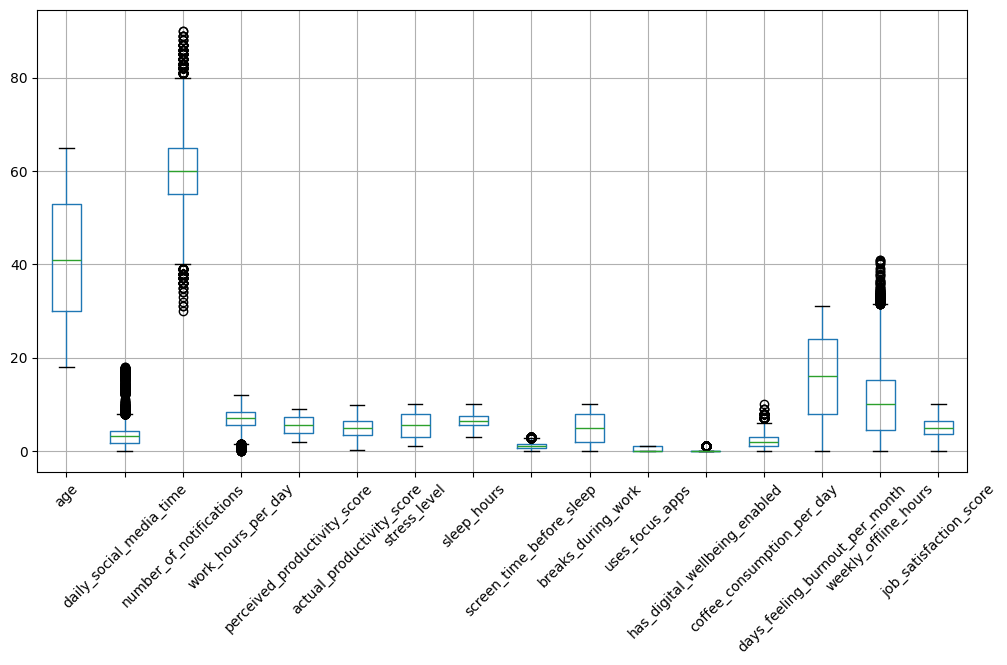

In [23]:
#checking for outliers using boxplot
plt.figure(figsize=(12,6))
file.boxplot()
plt.xticks(rotation=45)
plt.show()

In [25]:
#finding outliers using Interquartile Range method
#selecting only numerical columns for quantile calculation
numerical_file = file[numerical_cols]

Q1 = numerical_file.quantile(0.25)
Q3 = numerical_file.quantile(0.75)
IQR = Q3 - Q1

#find outliers
outliers = ((numerical_file < (Q1 - 1.5 * IQR)) | (numerical_file > (Q3 + 1.5 * IQR)))

#count outliers per column
outliers.sum()

,0
age,0
daily_social_media_time,348
number_of_notifications,261
work_hours_per_day,97
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0
sleep_hours,0
screen_time_before_sleep,198
breaks_during_work,0


In [28]:
le = LabelEncoder()

# Apply encoding to all categorical columns
for col in file.select_dtypes(include='object').columns:
    file[col] = le.fit_transform(file[col])

In [29]:
file.head()
file.dtypes

,0
age,int64
gender,int64
job_type,int64
daily_social_media_time,float64
social_platform_preference,int64
number_of_notifications,int64
work_hours_per_day,float64
perceived_productivity_score,float64
actual_productivity_score,float64
stress_level,float64


In [39]:
#Standardization
y =  file['perceived_productivity_score']
X = file.drop(['perceived_productivity_score', 'actual_productivity_score'], axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)
X.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,1.049017,0.771460,1.466684,0.540011,-1.422625,0.134811,-0.118753,-0.545834,-0.988958,-0.964471,0.947731,-0.655745,-0.572116,1.418913,-0.492507,1.588729,0.678317
1,0.326212,0.771460,-0.288586,0.068890,1.414303,-0.124134,1.090505,0.535697,-0.997998,-0.563049,0.632640,1.524983,1.747899,0.000496,1.020549,-1.423109,-0.767662
2,-0.685715,0.771460,-0.873676,0.000000,1.414303,-0.383079,0.460609,-0.545834,1.488741,-0.638019,-1.572998,1.524983,-0.572116,0.709705,0.155946,-0.005303,-1.231226
3,1.338138,-0.982922,1.466684,0.000000,-1.422625,-0.124134,-0.318248,0.175187,-0.319667,0.284622,-1.257907,-0.655745,-0.572116,-1.417920,-1.249034,1.856513,-1.597768
4,-1.191679,0.771460,0.296504,0.000000,-0.004161,0.782174,-0.388795,0.535697,-0.782289,1.352857,-1.257907,-0.655745,1.747899,-0.708712,1.560925,0.040227,2.337964


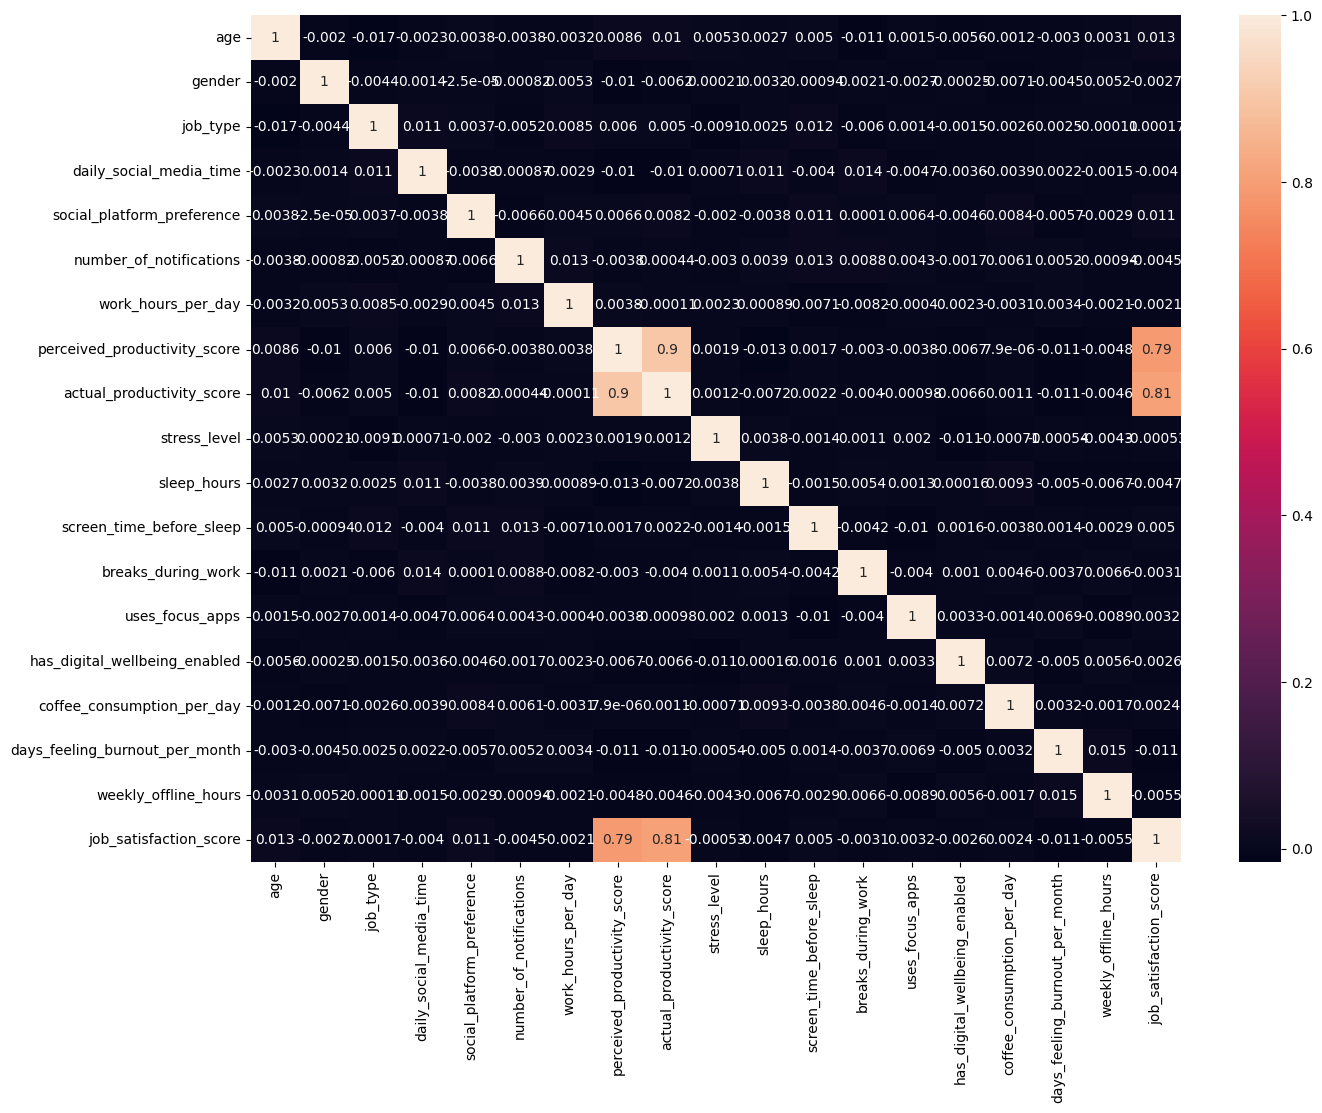

In [45]:
plt.figure(figsize=(15,11))
sns.heatmap(file.corr(), annot=True)
plt.show()

In [46]:
#perceived_productivity_score and actual_productivity_score have high correlation
file.drop(['actual_productivity_score'], axis=1, inplace=True)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
#linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [52]:
#Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [53]:
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Linear Regression:
MAE: 0.9499221580917363
MSE: 1.4375748625758393
R2 Score: 0.6257055634751518

Decision Tree:
MAE: 1.3198866978258854
MSE: 2.895586108906694
R2 Score: 0.24609020423433237


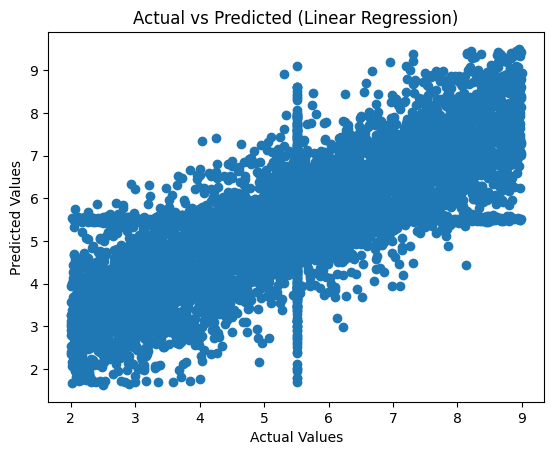

In [54]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [57]:
#CLASSIFICATION
y_class = pd.cut(
    file['perceived_productivity_score'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)


In [58]:
y_class.value_counts()

,count
perceived_productivity_score,
Medium,10996
High,9536
Low,9468


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [61]:
#Logistic Regression
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

y_pred_lr = lr_clf.predict(X_test)

In [63]:
#Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

In [65]:
#Evaluation Metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.683
[[1375   12  473]
 [  15 1377  508]
 [ 475  419 1346]]
              precision    recall  f1-score   support

        High       0.74      0.74      0.74      1860
         Low       0.76      0.72      0.74      1900
      Medium       0.58      0.60      0.59      2240

    accuracy                           0.68      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.69      0.68      0.68      6000


Decision Tree Accuracy: 0.5606666666666666
[[1184   98  578]
 [ 129 1156  615]
 [ 625  591 1024]]
              precision    recall  f1-score   support

        High       0.61      0.64      0.62      1860
         Low       0.63      0.61      0.62      1900
      Medium       0.46      0.46      0.46      2240

    accuracy                           0.56      6000
   macro avg       0.57      0.57      0.57      6000
weighted avg       0.56      0.56      0.56      6000



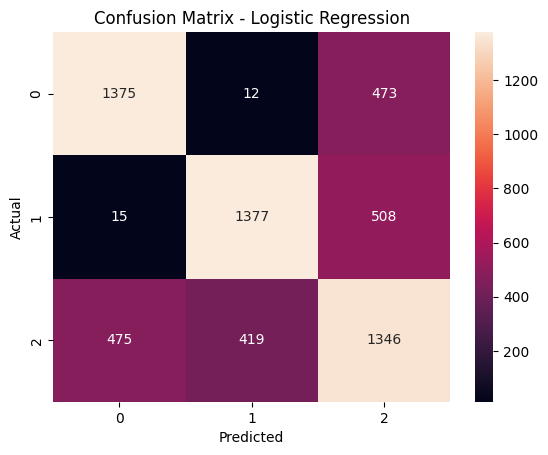

In [66]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()